# Preprocessing

Loads the UN General Debate speeches, merges in speaker and country metadata, and produces cleaned tokens for text analysis.

In [1]:
import os
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\30690\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\30690\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\30690\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Step 1 — Load speeches

In [2]:
txt_folder = '../datasets/TXT'

rows = []
for session_folder in sorted(os.listdir(txt_folder)):
    folder_path = os.path.join(txt_folder, session_folder)
    for filename in sorted(os.listdir(folder_path)):
        iso_code, session, year = filename.replace('.txt', '').split('_')
        file_path = os.path.join(folder_path, filename)
        with open(file_path, encoding='utf-8') as f:
            speech = f.read()
        rows.append({
            'Session': int(session),
            'Year': int(year),
            'ISO-alpha3 Code': iso_code,
            'Speech': speech
        })

df = pd.DataFrame(rows)
print(len(df))
df.head()

11141


,Session,Year,ISO-alpha3 Code,Speech
0,1,1946,ARG,At the resumption of the first session of the ...
1,1,1946,AUS,The General Assembly of the United Nations is ...
2,1,1946,BEL,The\tprincipal organs of the United Nations ha...
3,1,1946,BLR,As more than a year has elapsed since the Unit...
4,1,1946,BOL,Coming to this platform where so many distingu...


## Step 2 — Merge in speaker and country metadata

In [3]:
speakers = pd.read_excel('../datasets/Speakers_by_session.xlsx')
speakers = speakers.rename(columns={'ISO Code': 'ISO-alpha3 Code', 'Name of Person Speaking': 'SpeakerName'})
speakers = speakers[['Session', 'Year', 'ISO-alpha3 Code', 'SpeakerName', 'Post']]

df = df.merge(speakers, on=['ISO-alpha3 Code', 'Session', 'Year'], how='left')

unsd = pd.read_csv('../datasets/UNSD — Methodology.csv', sep=';')
unsd = unsd[['ISO-alpha3 Code', 'Country or Area', 'Region Name', 'Sub-region Name', 'Least Developed Countries (LDC)']]

df = df.merge(unsd, on='ISO-alpha3 Code', how='left')

df = df.set_index(['Year', 'ISO-alpha3 Code'])

print(df.shape)
df.head()

(11158, 8)


Session  \
Year ISO-alpha3 Code            
1946 ARG                    1   
     AUS                    1   
     BEL                    1   
     BLR                    1   
     BOL                    1   

                                                                 Speech  \
Year ISO-alpha3 Code                                                      
1946 ARG              At the resumption of the first session of the ...   
     AUS              The General Assembly of the United Nations is ...   
     BEL              The\tprincipal organs of the United Nations ha...   
     BLR              As more than a year has elapsed since the Unit...   
     BOL              Coming to this platform where so many distingu...   

                             SpeakerName Post  \
Year ISO-alpha3 Code                            
1946 ARG                        Mr. Arce  NaN   
     AUS                       Mr. Makin  NaN   
     BEL              Mr. Van Langenhove  NaN   
     BLR                     Mr. Kiselev  NaN   
     BOL               Mr. Costa du Rels  NaN   

                                       Country or Area Region Name  \
Year ISO-alpha3 Code                                                 
1946 ARG                                     Argentina    Americas   
     AUS                                     Australia     Oceania   
     BEL                                       Belgium      Europe   
     BLR                                       Belarus      Europe   
     BOL              Bolivia (Plurinational State of)    Americas   

                                      Sub-region Name  \
Year ISO-alpha3 Code                                    
1946 ARG              Latin America and the Caribbean   
     AUS                    Australia and New Zealand   
     BEL                               Western Europe   
     BLR                               Eastern Europe   
     BOL              Latin America and the Caribbean   

                     Least Developed Countries (LDC)  
Year ISO-alpha3 Code                                  
1946 ARG                                         NaN  
     AUS                                         NaN  
     BEL                                         NaN  
     BLR                                         NaN  
     BOL                                         NaN

## Step 3 — Text preprocessing

In [4]:
df['CleanText'] = df['Speech'].str.lower()
df['CleanText'] = df['CleanText'].str.replace(r'\s+', ' ', regex=True).str.strip()

df.head()

Session  \
Year ISO-alpha3 Code            
1946 ARG                    1   
     AUS                    1   
     BEL                    1   
     BLR                    1   
     BOL                    1   

                                                                 Speech  \
Year ISO-alpha3 Code                                                      
1946 ARG              At the resumption of the first session of the ...   
     AUS              The General Assembly of the United Nations is ...   
     BEL              The\tprincipal organs of the United Nations ha...   
     BLR              As more than a year has elapsed since the Unit...   
     BOL              Coming to this platform where so many distingu...   

                             SpeakerName Post  \
Year ISO-alpha3 Code                            
1946 ARG                        Mr. Arce  NaN   
     AUS                       Mr. Makin  NaN   
     BEL              Mr. Van Langenhove  NaN   
     BLR                     Mr. Kiselev  NaN   
     BOL               Mr. Costa du Rels  NaN   

                                       Country or Area Region Name  \
Year ISO-alpha3 Code                                                 
1946 ARG                                     Argentina    Americas   
     AUS                                     Australia     Oceania   
     BEL                                       Belgium      Europe   
     BLR                                       Belarus      Europe   
     BOL              Bolivia (Plurinational State of)    Americas   

                                      Sub-region Name  \
Year ISO-alpha3 Code                                    
1946 ARG              Latin America and the Caribbean   
     AUS                    Australia and New Zealand   
     BEL                               Western Europe   
     BLR                               Eastern Europe   
     BOL              Latin America and the Caribbean   

                     Least Developed Countries (LDC)  \
Year ISO-alpha3 Code                                   
1946 ARG                                         NaN   
     AUS                                         NaN   
     BEL                                         NaN   
     BLR                                         NaN   
     BOL                                         NaN   

                                                              CleanText  
Year ISO-alpha3 Code                                                     
1946 ARG              at the resumption of the first session of the ...  
     AUS              the general assembly of the united nations is ...  
     BEL              the principal organs of the united nations hav...  
     BLR              as more than a year has elapsed since the unit...  
     BOL              coming to this platform where so many distingu...

In [5]:
stop_words = set(stopwords.words('english'))
custom_noise = ['united', 'nations', 'assembly', 'general', 'session', 'mr', 'president']
stop_words.update(custom_noise)

clean_tokens_list = []
for text in df['CleanText']:
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    clean_tokens_list.append(tokens)

df['CleanTokens'] = clean_tokens_list
df.head()

Session  \
Year ISO-alpha3 Code            
1946 ARG                    1   
     AUS                    1   
     BEL                    1   
     BLR                    1   
     BOL                    1   

                                                                 Speech  \
Year ISO-alpha3 Code                                                      
1946 ARG              At the resumption of the first session of the ...   
     AUS              The General Assembly of the United Nations is ...   
     BEL              The\tprincipal organs of the United Nations ha...   
     BLR              As more than a year has elapsed since the Unit...   
     BOL              Coming to this platform where so many distingu...   

                             SpeakerName Post  \
Year ISO-alpha3 Code                            
1946 ARG                        Mr. Arce  NaN   
     AUS                       Mr. Makin  NaN   
     BEL              Mr. Van Langenhove  NaN   
     BLR                     Mr. Kiselev  NaN   
     BOL               Mr. Costa du Rels  NaN   

                                       Country or Area Region Name  \
Year ISO-alpha3 Code                                                 
1946 ARG                                     Argentina    Americas   
     AUS                                     Australia     Oceania   
     BEL                                       Belgium      Europe   
     BLR                                       Belarus      Europe   
     BOL              Bolivia (Plurinational State of)    Americas   

                                      Sub-region Name  \
Year ISO-alpha3 Code                                    
1946 ARG              Latin America and the Caribbean   
     AUS                    Australia and New Zealand   
     BEL                               Western Europe   
     BLR                               Eastern Europe   
     BOL              Latin America and the Caribbean   

                     Least Developed Countries (LDC)  \
Year ISO-alpha3 Code                                   
1946 ARG                                         NaN   
     AUS                                         NaN   
     BEL                                         NaN   
     BLR                                         NaN   
     BOL                                         NaN   

                                                              CleanText  \
Year ISO-alpha3 Code                                                      
1946 ARG              at the resumption of the first session of the ...   
     AUS              the general assembly of the united nations is ...   
     BEL              the principal organs of the united nations hav...   
     BLR              as more than a year has elapsed since the unit...   
     BOL              coming to this platform where so many distingu...   

                                                            CleanTokens  
Year ISO-alpha3 Code                                                     
1946 ARG              [resumption, first, argentine, delegation, wis...  
     AUS              [meeting, time, hospitable, city, new, york, e...  
     BEL              [principal, organs, functioning, nearly, nine,...  
     BLR              [year, elapsed, since, charter, signed, san, f...  
     BOL              [coming, platform, many, distinguished, eloque...

## Step 4 — Profiling plots

A handful of basic charts to sanity-check the corpus before doing anything else with it - These don't change any data, they're just here so obvious issues (missing
years, a discontinuity in speech length, patchy metadata)

In [6]:
import matplotlib.pyplot as plt

FLAG_COLOR = "#DC2626"
GRID_COLOR = "#E5E7EB"

df['WordCount'] = df['Speech'].str.split().str.len()
df['WordCount'].describe()

count    11158.000000
mean      2911.146801
std       1533.927680
min        423.000000
25%       1867.000000
50%       2553.000000
75%       3632.000000
max      22003.000000
Name: WordCount, dtype: float64

### 4a. Speeches per year

Total speech volume by year. A missing or unusually low bar is a quick way to spot an incomplete session folder.

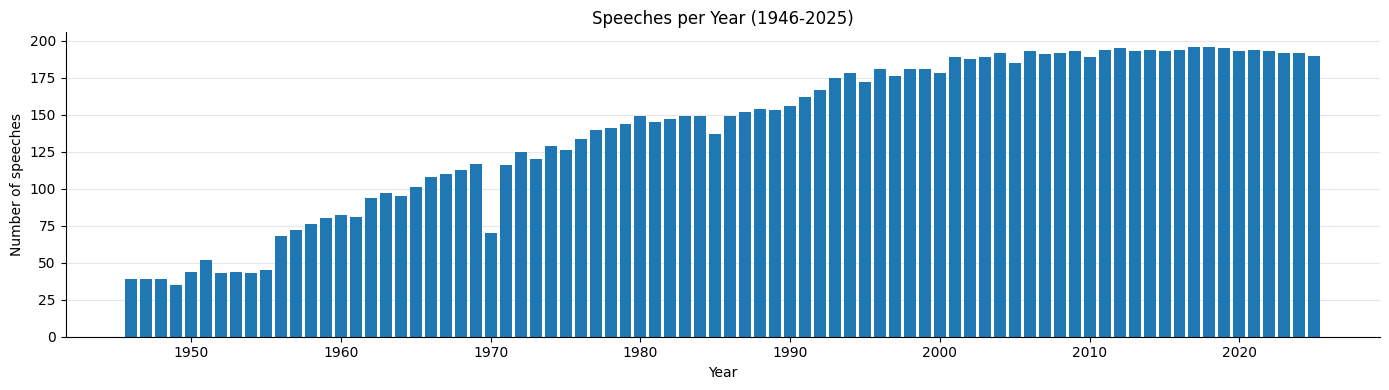

In [9]:
year_min = int(df.index.get_level_values('Year').min())
year_max = int(df.index.get_level_values('Year').max())
speeches_per_year = df.groupby(level='Year').size().reindex(range(year_min, year_max + 1), fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(speeches_per_year.index, speeches_per_year.values, width=0.8)
ax.set_title(f"Speeches per Year ({year_min}-{year_max})")
ax.set_xlabel("Year")
ax.set_ylabel("Number of speeches")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 4b. Word count distribution

Very short "speeches" are usually an extraction failure rather than a genuinely brief remark.

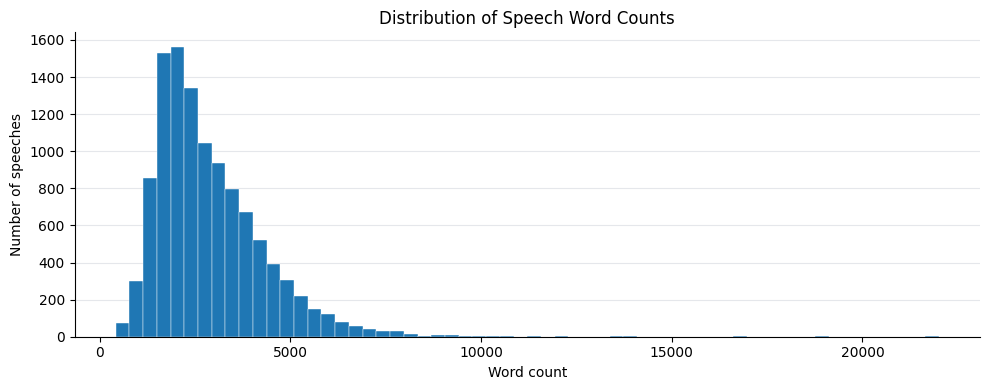

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['WordCount'], bins=60, edgecolor="white", linewidth=0.3)
ax.set_title("Distribution of Speech Word Counts")
ax.set_xlabel("Word count")
ax.set_ylabel("Number of speeches")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 4c. Average word count per year

Watch the 2024-2025 discontinuity: those two sessions used OCR/GPT-4o translation and Whisper audio transcription
instead of the usual official transcripts, so a jump here reflects a change in pipeline, not necessarily in what
was actually said.

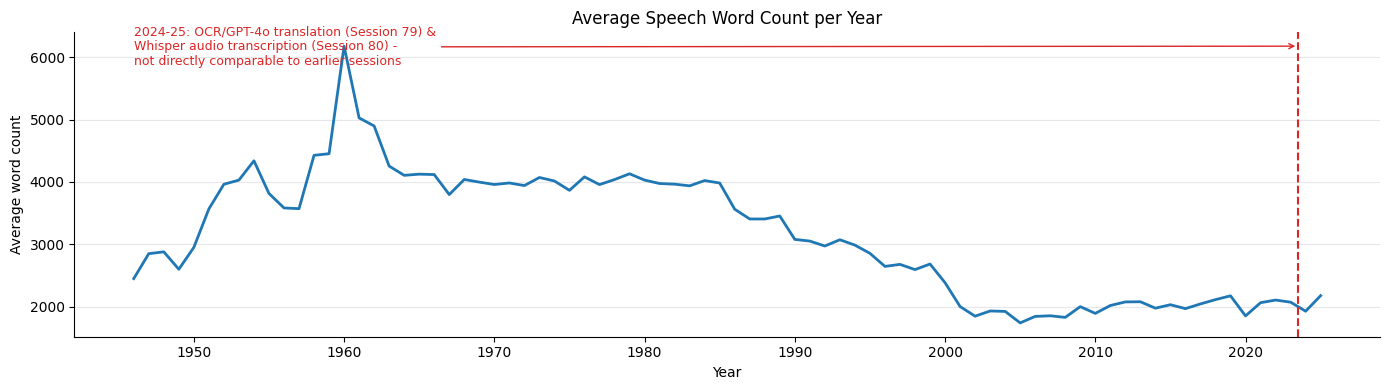

In [13]:
avg_wordcount_per_year = df.groupby(level='Year')['WordCount'].mean().reindex(range(year_min, year_max + 1))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(avg_wordcount_per_year.index, avg_wordcount_per_year.values, linewidth=2)
ax.axvline(2023.5, color=FLAG_COLOR, linestyle="--", linewidth=1.5)
ax.annotate(
    "2024-25: OCR/GPT-4o translation (Session 79) &\nWhisper audio transcription (Session 80) -\n"
    "not directly comparable to earlier sessions",
    xy=(2023.5, avg_wordcount_per_year.max()),
    xytext=(year_min, avg_wordcount_per_year.max() * 0.95),
    fontsize=9, color=FLAG_COLOR,
    arrowprops=dict(arrowstyle="->", color=FLAG_COLOR, linewidth=1),
)
ax.set_title("Average Speech Word Count per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Average word count")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 4d. Country coverage

Countries with the fewest distinct years present — some of this is real (a country didn't exist yet, or stopped
attending), some of it can be a data gap, worth knowing before doing any country-level panel analysis.

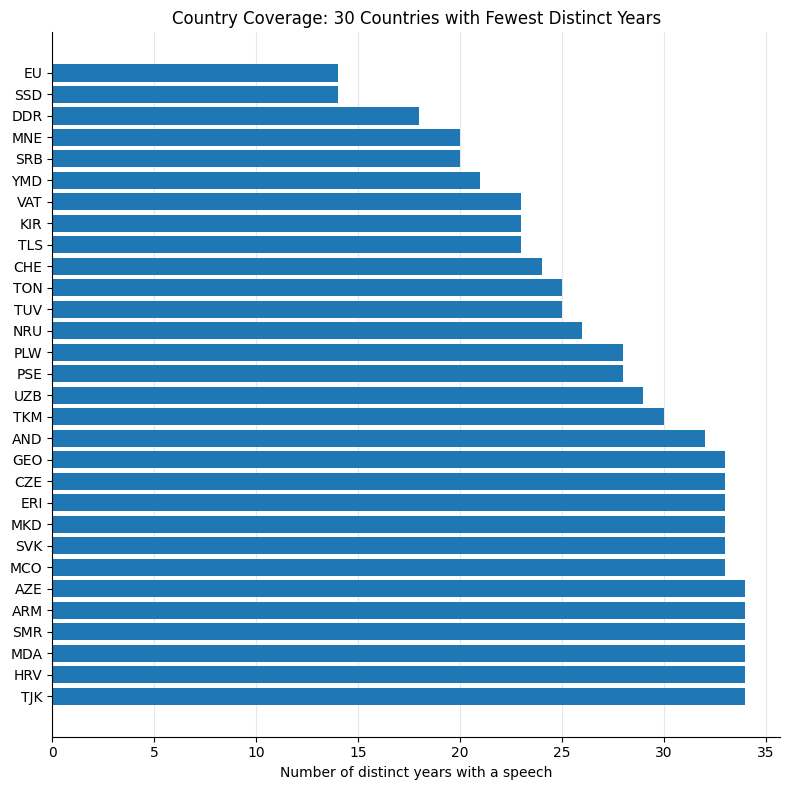

In [15]:
years_per_country = df.reset_index().groupby('ISO-alpha3 Code')['Year'].nunique().sort_values()

N_SHOW = 30
lowest = years_per_country.head(N_SHOW)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(lowest.index, lowest.values)
ax.set_title(f"Country Coverage: {N_SHOW} Countries with Fewest Distinct Years")
ax.set_xlabel("Number of distinct years with a speech")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 4e. Missing speaker "Post" by year

Confirms the known caveat that speaker role wasn't consistently recorded before 1994 — expect this to be high and
noisy before then, and much lower afterward.

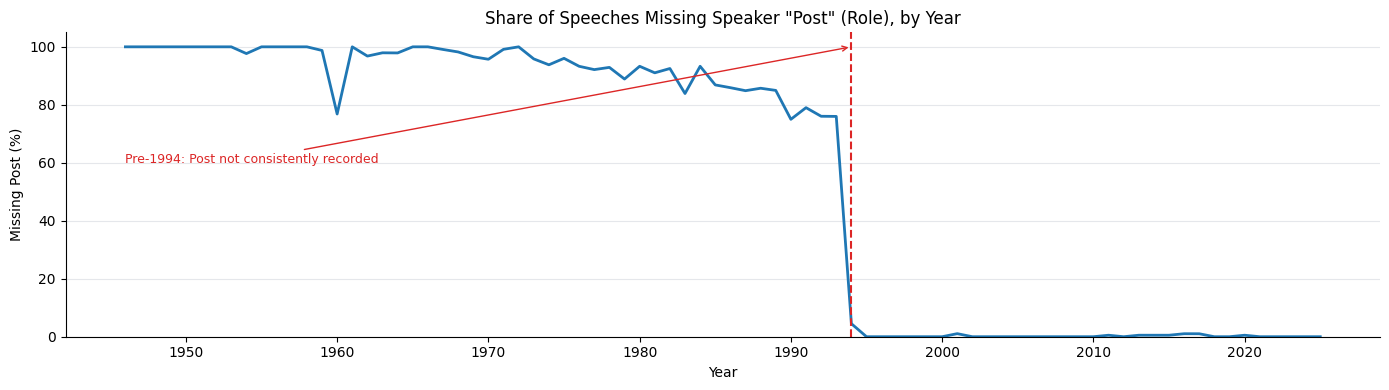

In [17]:
post_missing_by_year = df.groupby(level='Year')['Post'].apply(lambda s: s.isna().mean()).reindex(range(year_min, year_max + 1))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(post_missing_by_year.index, post_missing_by_year.values * 100, linewidth=2)
ax.axvline(1994, color=FLAG_COLOR, linestyle="--", linewidth=1.5)
ax.annotate(
    "Pre-1994: Post not consistently recorded",
    xy=(1994, 100), xytext=(year_min, 60),
    fontsize=9, color=FLAG_COLOR,
    arrowprops=dict(arrowstyle="->", color=FLAG_COLOR, linewidth=1),
)
ax.set_title('Share of Speeches Missing Speaker "Post" (Role), by Year')
ax.set_xlabel("Year")
ax.set_ylabel("Missing Post (%)")
ax.set_ylim(0, 105)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Save output

In [18]:
df.to_parquet('../datasets/speeches_simple_clean.parquet')

## Final columns

- Year (index)
- ISO-alpha3 Code (index)
- Session
- Speech
- SpeakerName
- Post
- Country or Area
- Region Name
- Sub-region Name
- Least Developed Countries (LDC)
- CleanText
- CleanTokens